In [11]:
import anndata
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy




In [23]:

# --- INIT ---

# which data to use
head_folder = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint'
hvg_to_use = 'transformed_X_outlier_variance' # transformed_X_outlier_variance
cluster_resolution = 0.05

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
cluster_df_fileout = '%s/clustering/res_%s/clusters.tsv' % (scvi_res_folder, str(cluster_resolution))



In [24]:
# --- LOAD ADATA ---

adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [25]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

<Figure size 432x288 with 0 Axes>

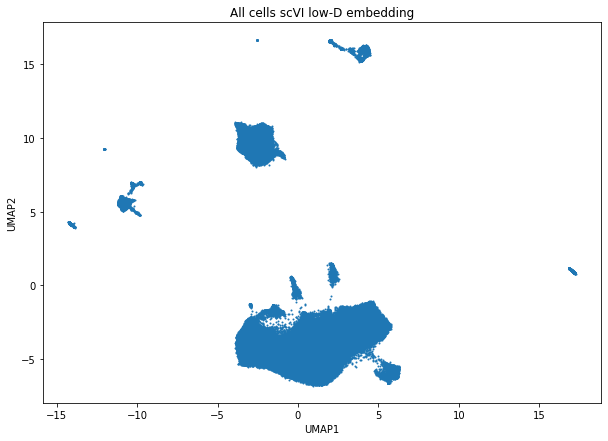

In [26]:
# --- VIZ UMAP ---

plt.clf()
plt.figure(figsize=(10,7))
plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("All cells scVI low-D embedding")
plt.show()






In [27]:
# --- MARKER DICT ---

marker_dict = {
    "SMC" : ["Myh11", "Acta2", "Tagln", "Cnn1"],
    'Modulated SMC' : ['Fn1', 'Lum', 'Frzb', 'Ly6c1', 'Ly6a', 'Vcam1'],
    "Fibroblast" : ['Serpinf1', 'Serping1', 'Cygb', 'Gsn'],
    'Macrophage 1' : ['C1qb'],
    'Macrophage 2' : ['Ctss'],
    'Macrophage' : ['Cd84'],
    'Endothelial' : ['Egfl7', 'Pecam1', 'Esam'],
    'T' : ['Cd3g', 'Cd3d', 'Lat'],
    'Transitioning SMC' : ['Rgs5']
}


In [28]:
# --- GET TRANSFORMED COUNTS FOR MARKER GENES ---

import sys
sys.path.insert(0,'/users/benauerbach/desktop/sc_phase_inference/src/preprocessing')
import data_encoding

marker_genes = []
for cell_type,l in marker_dict.items():
    marker_genes += l
marker_genes = list(filter(lambda x: x in adata.var_names,marker_genes))
adata_marker_genes = data_encoding.log_proportion_z_score(adata[:,marker_genes])




<Figure size 432x288 with 0 Axes>

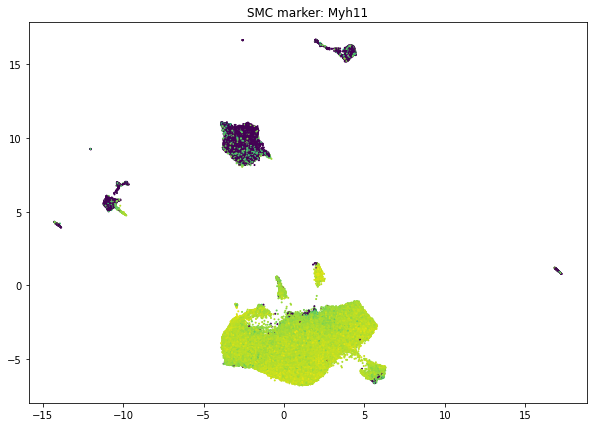

<Figure size 432x288 with 0 Axes>

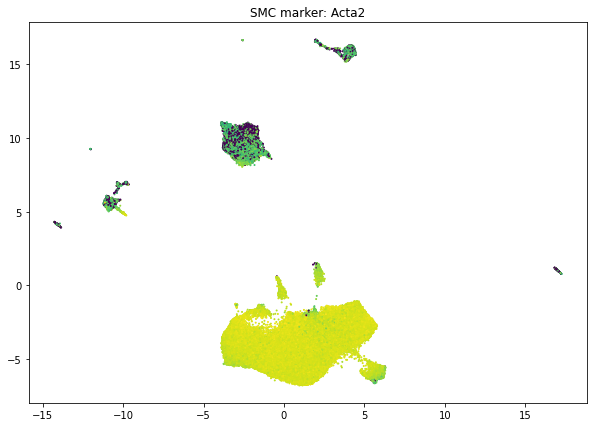

<Figure size 432x288 with 0 Axes>

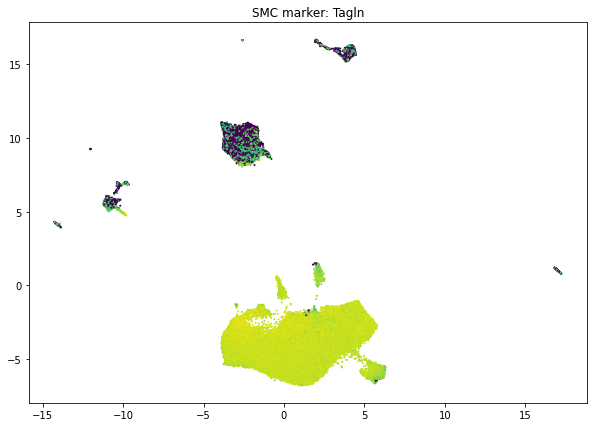

<Figure size 432x288 with 0 Axes>

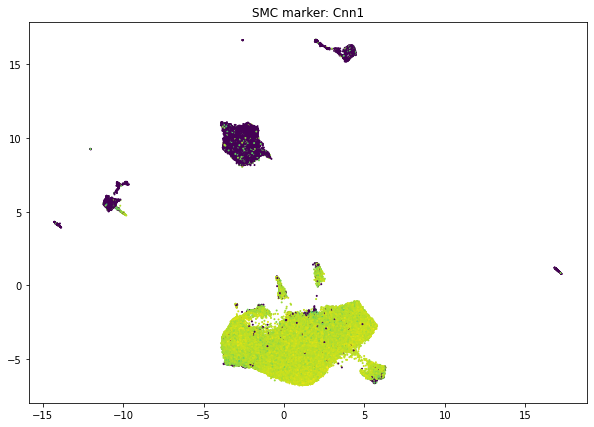

<Figure size 432x288 with 0 Axes>

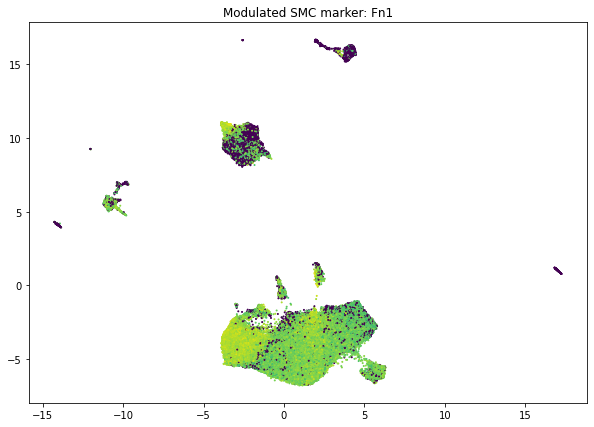

<Figure size 432x288 with 0 Axes>

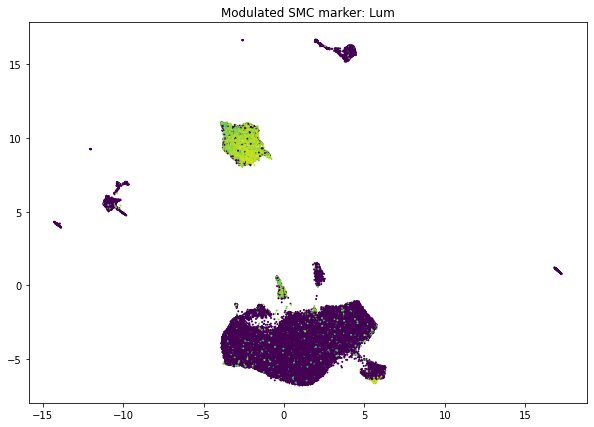

<Figure size 432x288 with 0 Axes>

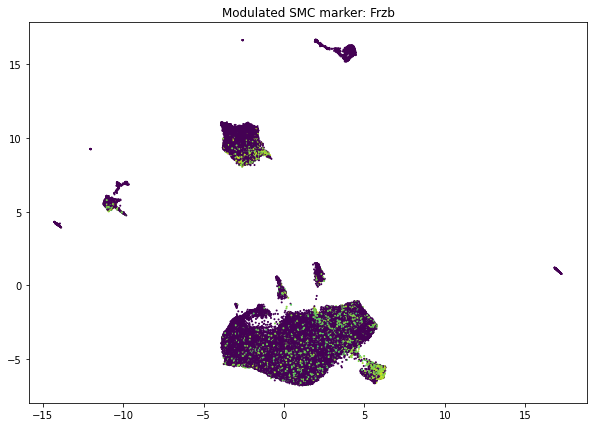

<Figure size 432x288 with 0 Axes>

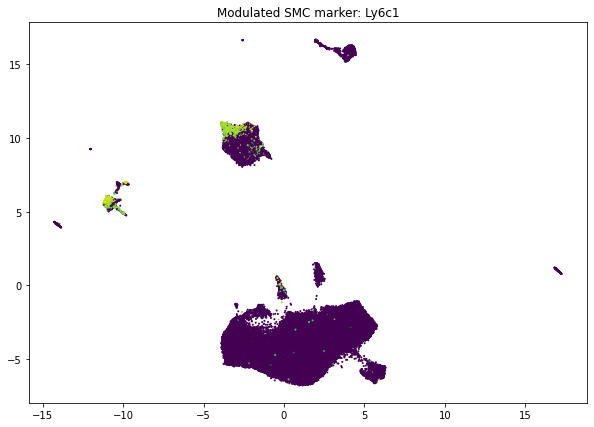

<Figure size 432x288 with 0 Axes>

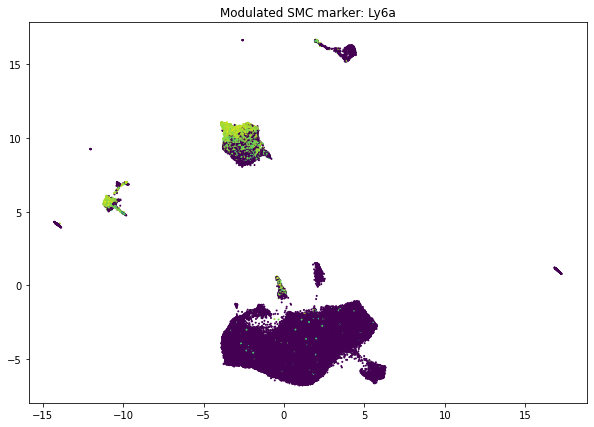

<Figure size 432x288 with 0 Axes>

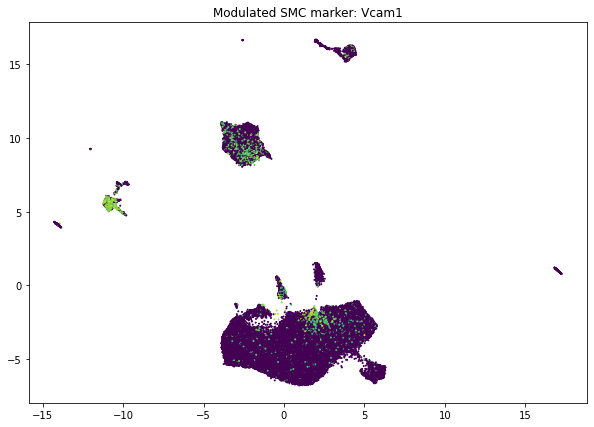

<Figure size 432x288 with 0 Axes>

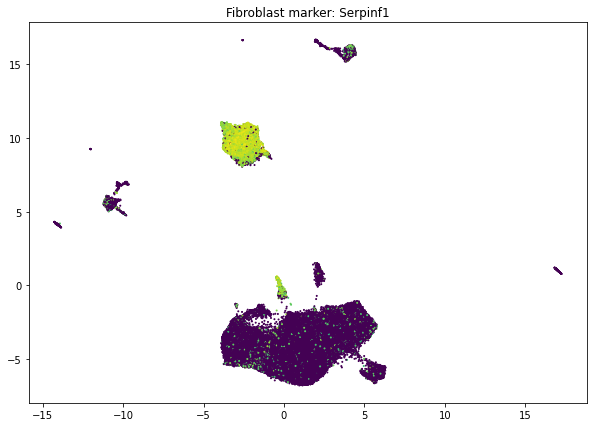

<Figure size 432x288 with 0 Axes>

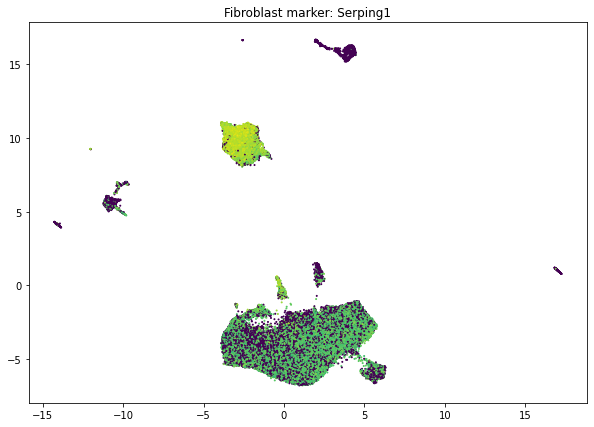

<Figure size 432x288 with 0 Axes>

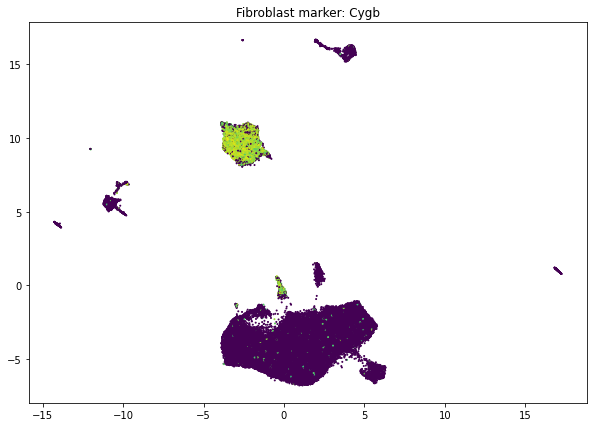

<Figure size 432x288 with 0 Axes>

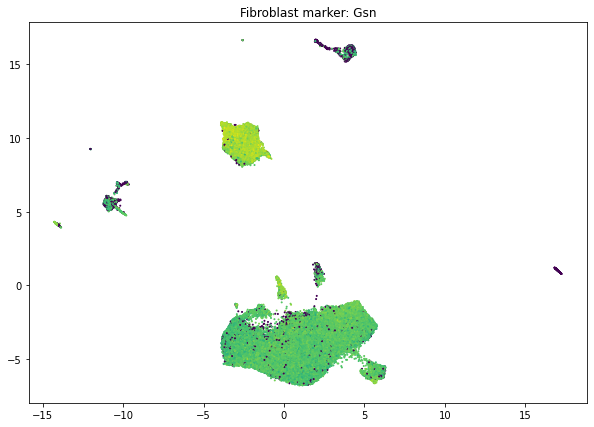

<Figure size 432x288 with 0 Axes>

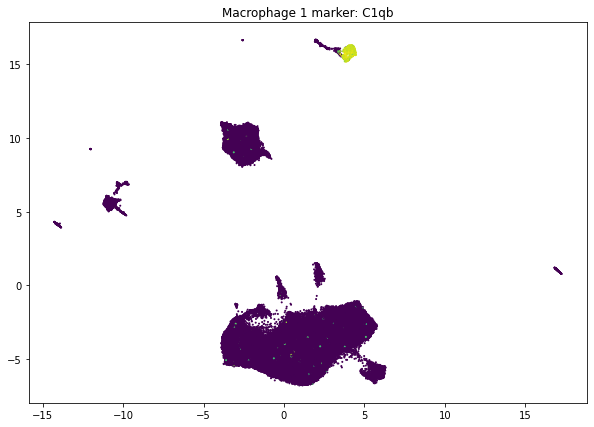

<Figure size 432x288 with 0 Axes>

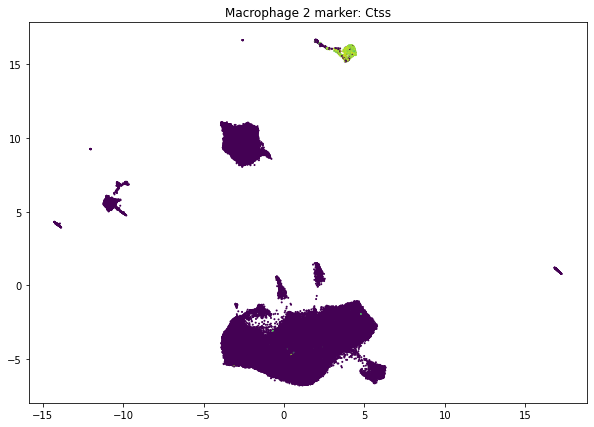

<Figure size 432x288 with 0 Axes>

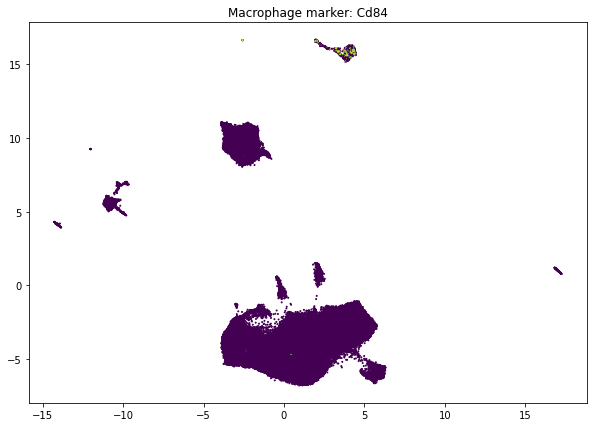

<Figure size 432x288 with 0 Axes>

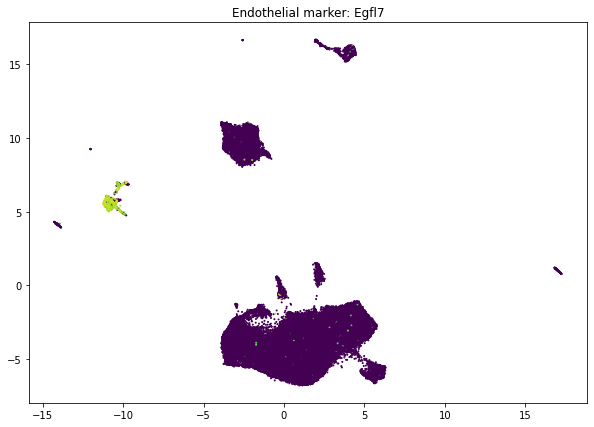

<Figure size 432x288 with 0 Axes>

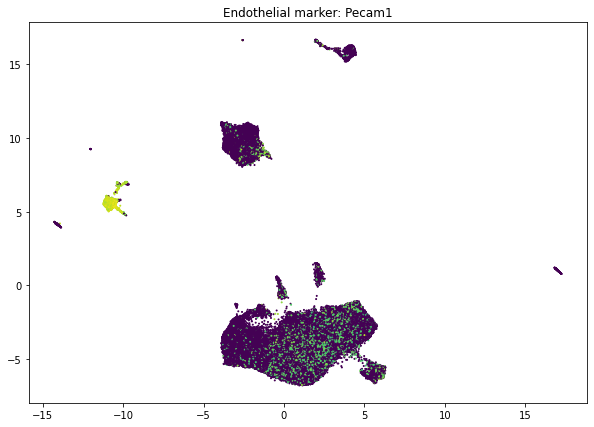

<Figure size 432x288 with 0 Axes>

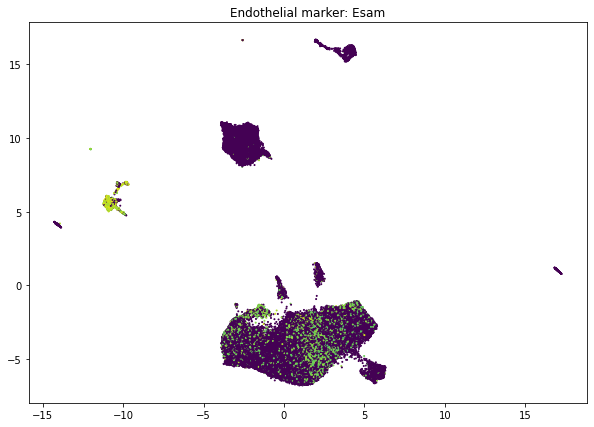

<Figure size 432x288 with 0 Axes>

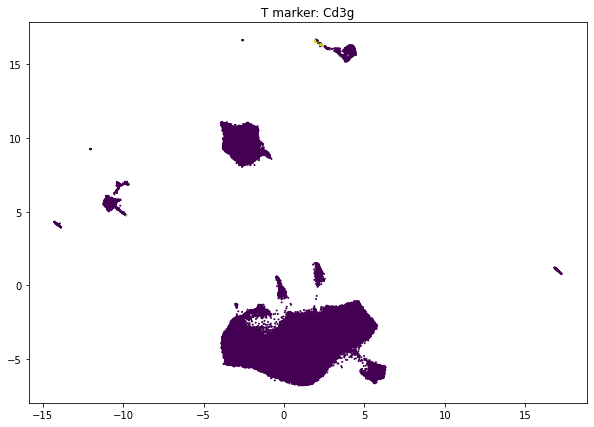

<Figure size 432x288 with 0 Axes>

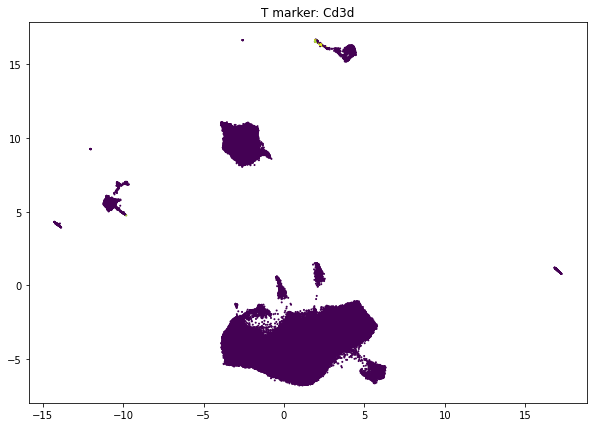

<Figure size 432x288 with 0 Axes>

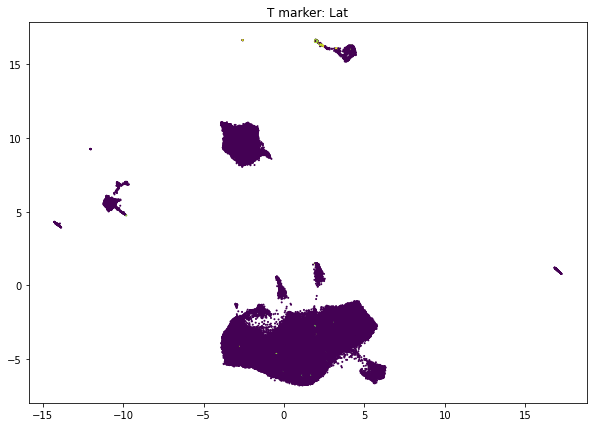

<Figure size 432x288 with 0 Axes>

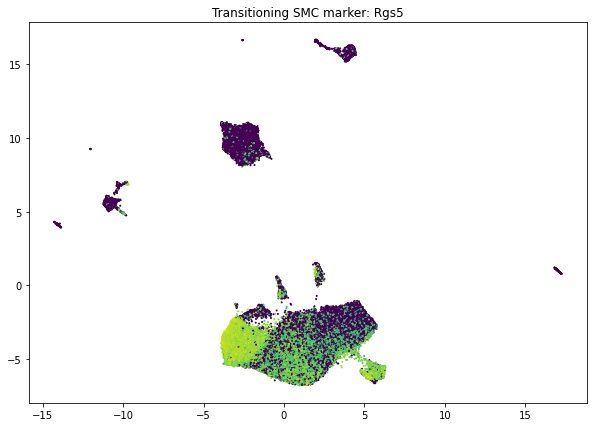

In [29]:
# --- VIZ BY MARKER GENES ---


for cell_type, marker_list in marker_dict.items():
    for marker in marker_list:
    
        if marker not in adata_marker_genes.var_names:
            continue


        marker_vals = np.array(adata_marker_genes[:,marker].layers['X_transformed']).flatten()


        plt.clf()
        plt.figure(figsize=(10,7))
        plt.scatter(adata_marker_genes.obsm["X_scVI_umap"][:,0],adata_marker_genes.obsm["X_scVI_umap"][:,1],s=1,c = marker_vals)
        plt.title("%s marker: %s" % (cell_type,marker))
        plt.show()


        
        
        
        
        
        







<Figure size 432x288 with 0 Axes>

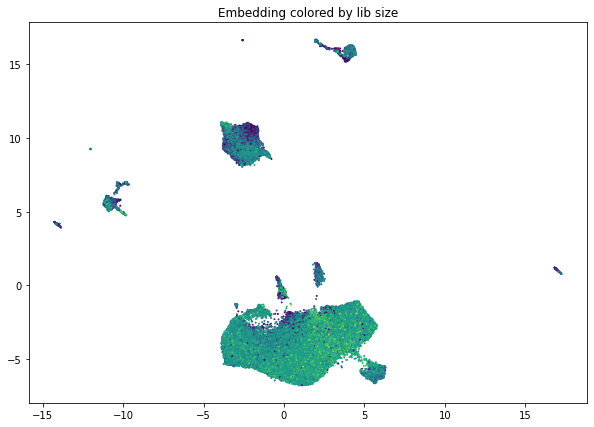

In [30]:
# --- VIZ BY LIB SIZE ---



plt.clf()
plt.figure(figsize=(10,7))
plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c = np.log10(adata.obs['lib_size']))
plt.title("Embedding colored by lib size")
plt.show()


        
        
        
        
        
        



/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

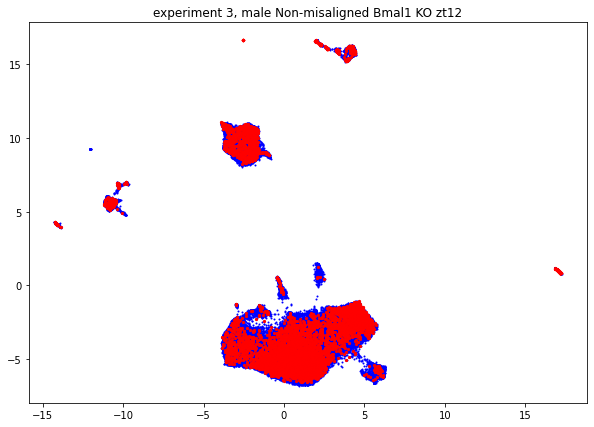

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

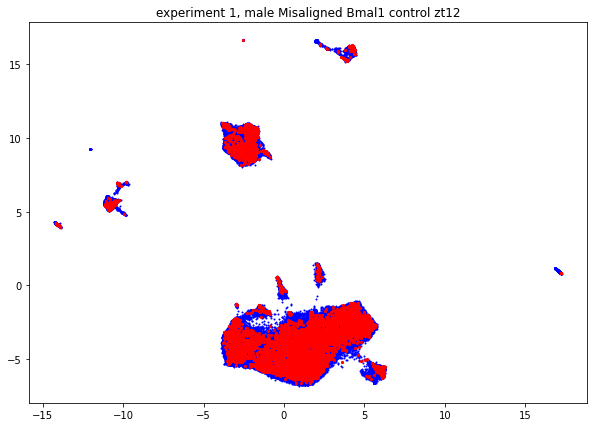

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

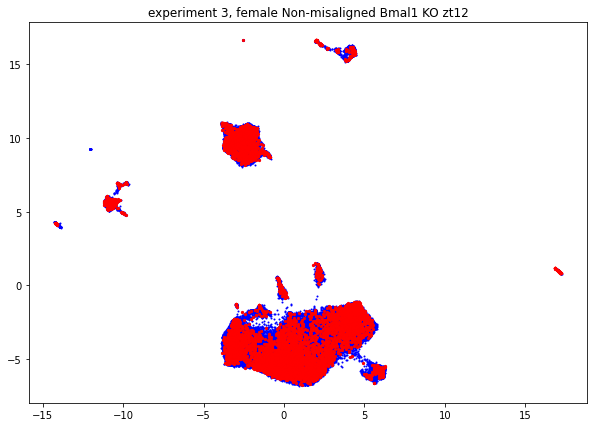

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

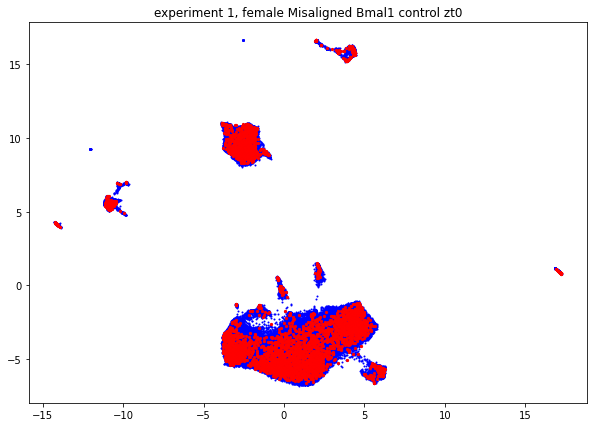

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

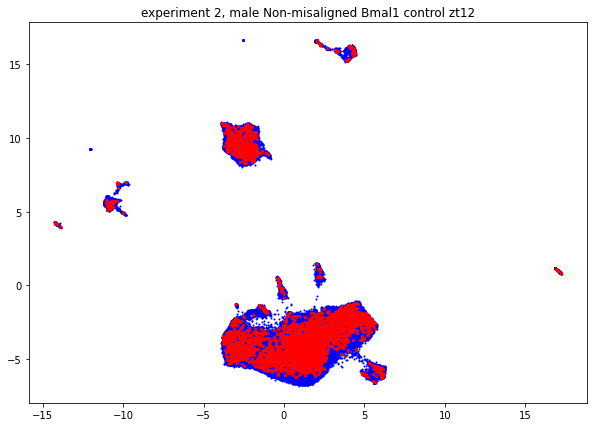

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

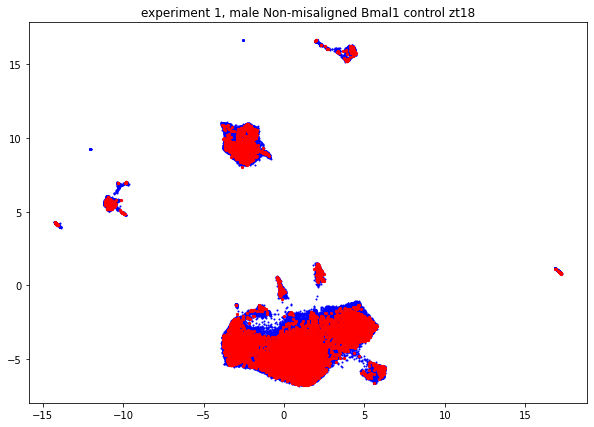

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

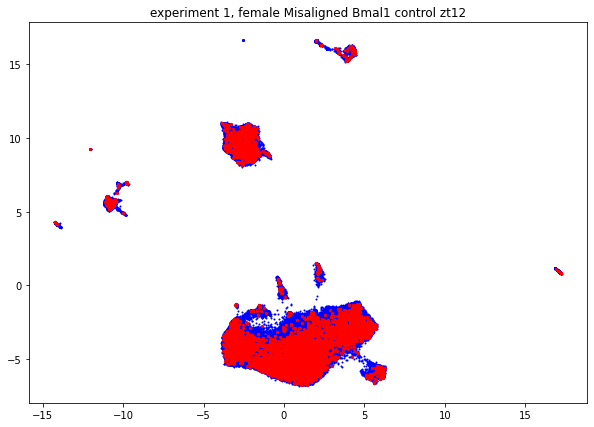

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

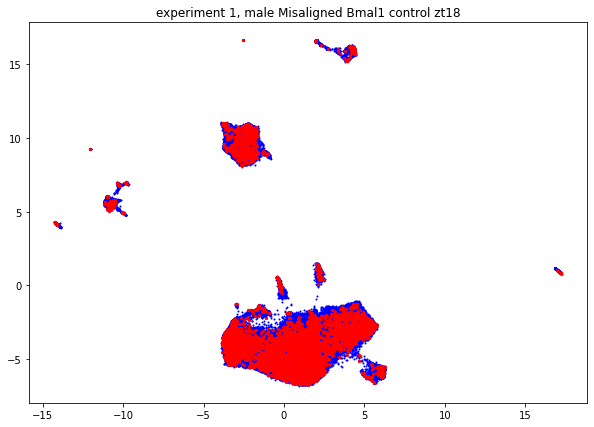

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

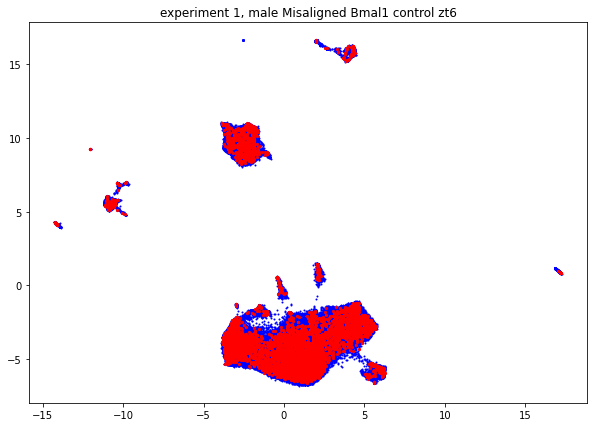

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

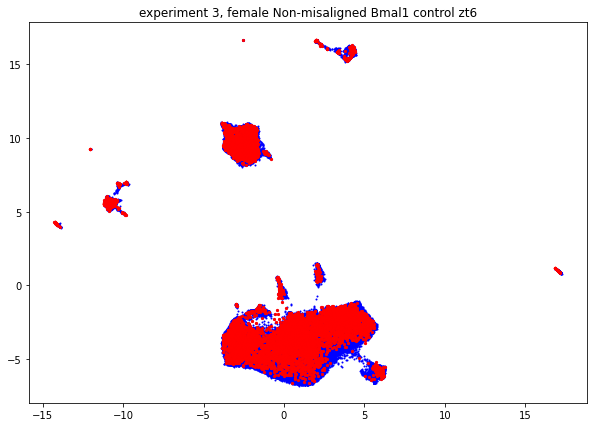

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

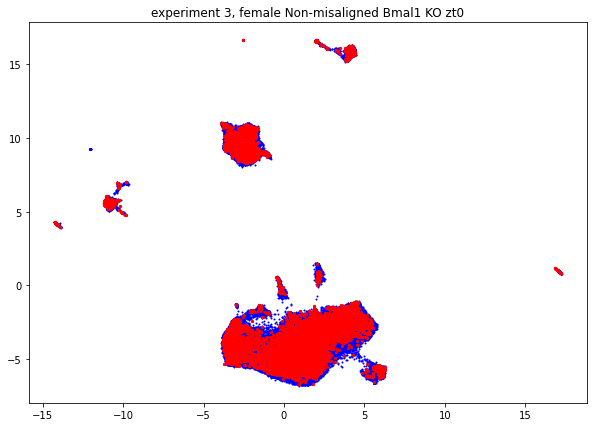

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

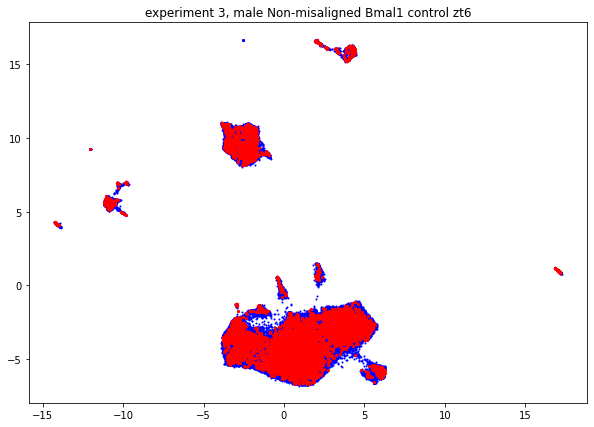

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

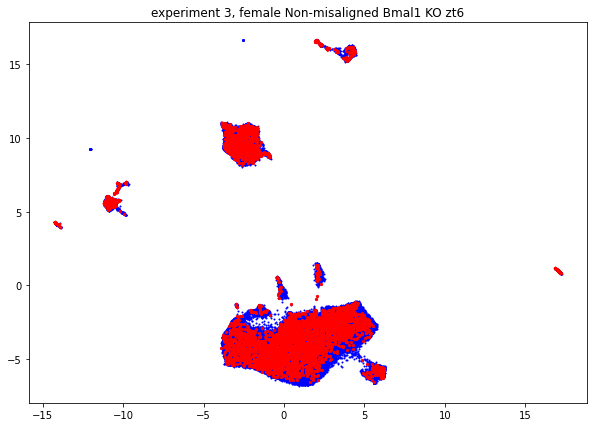

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

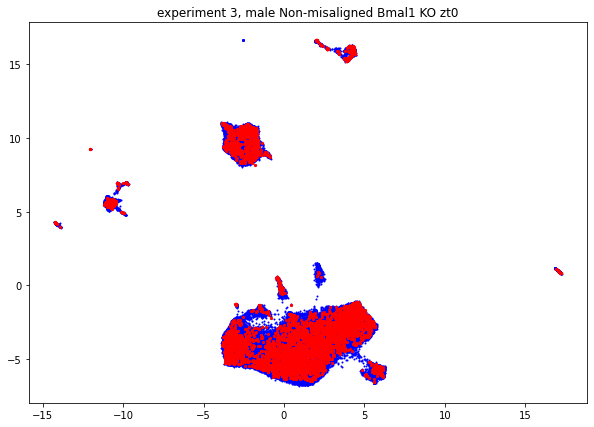

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

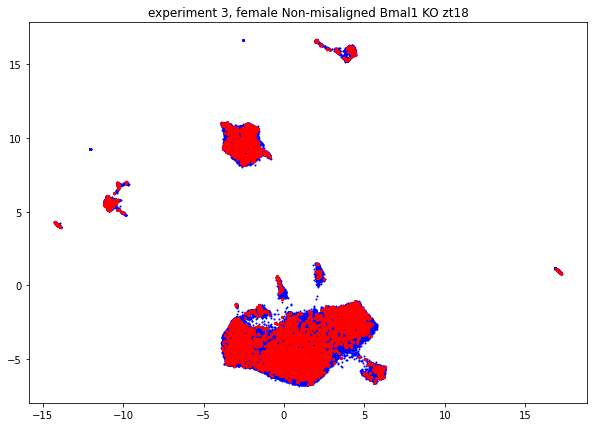

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

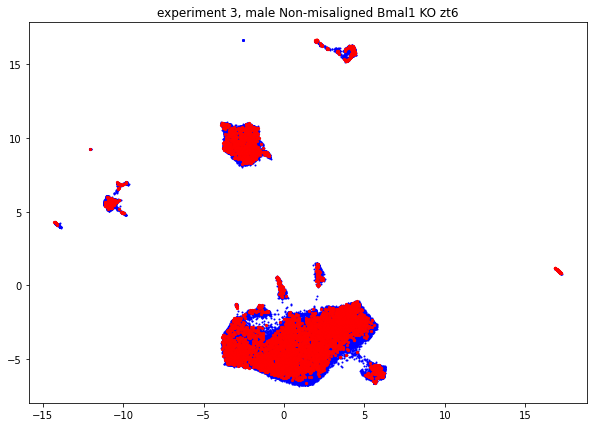

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

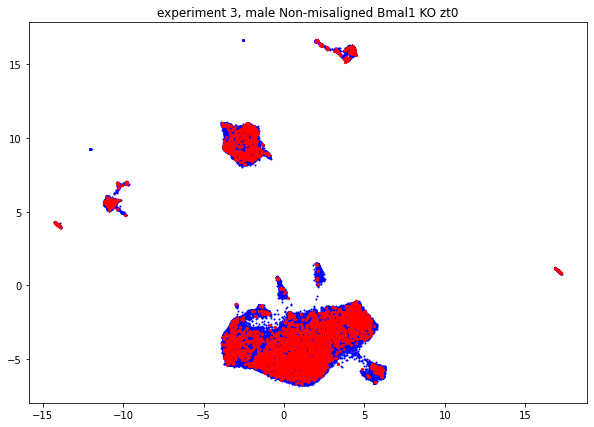

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

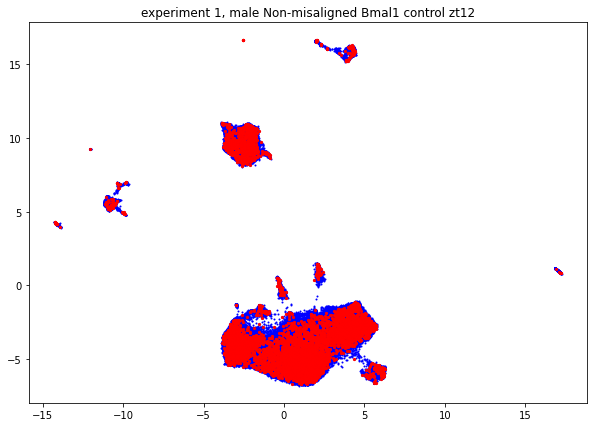

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

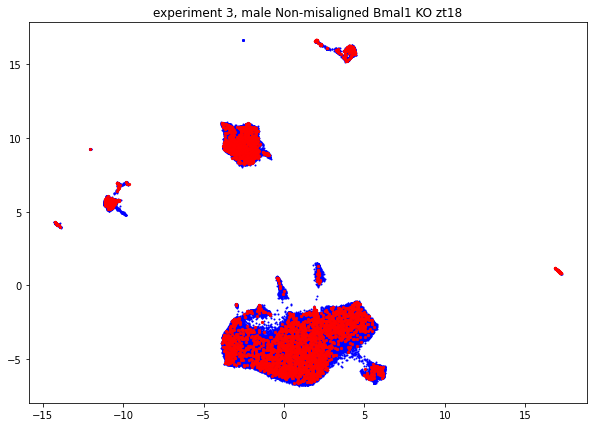

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

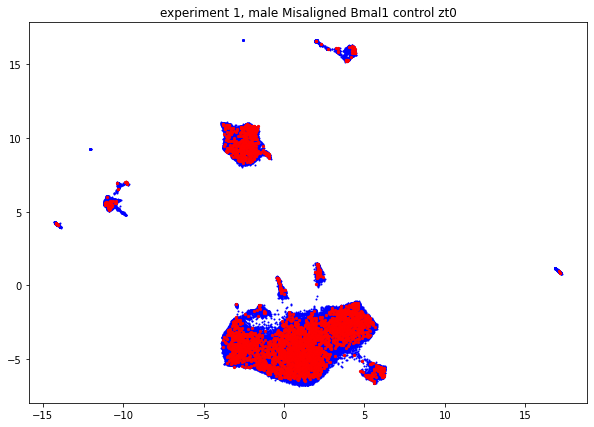

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

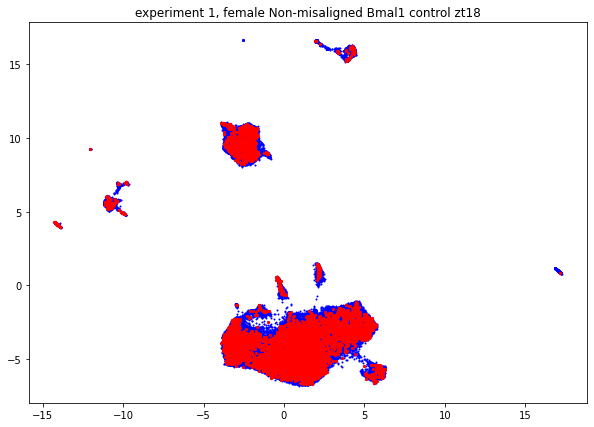

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

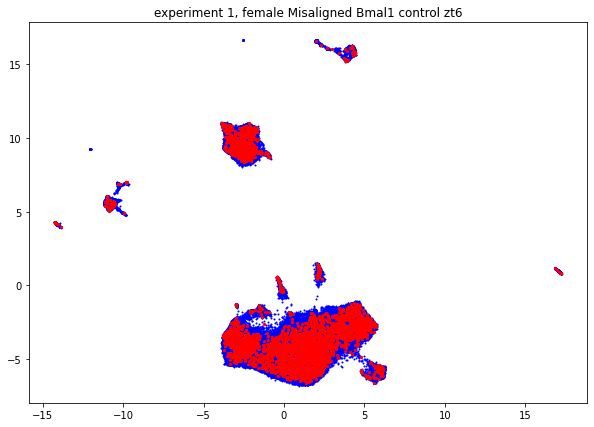

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

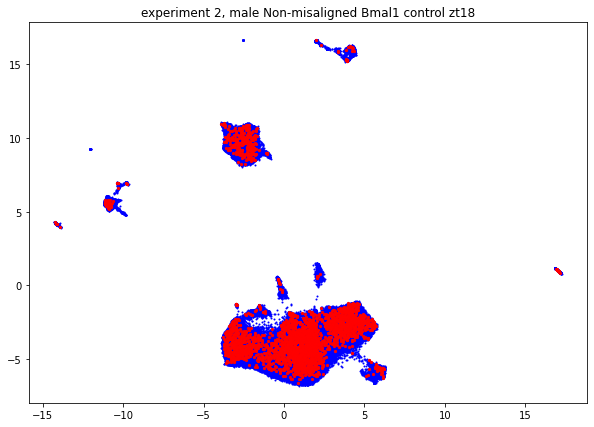

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

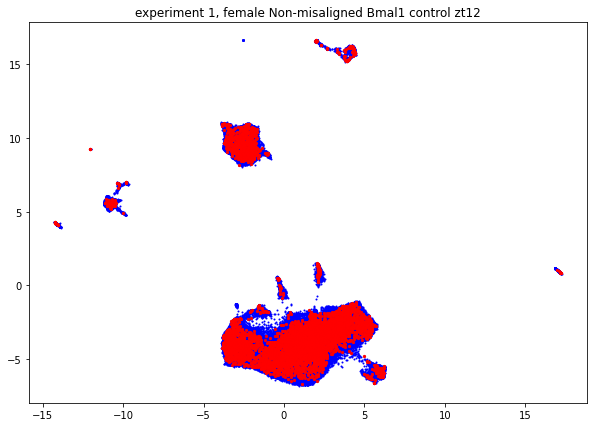

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

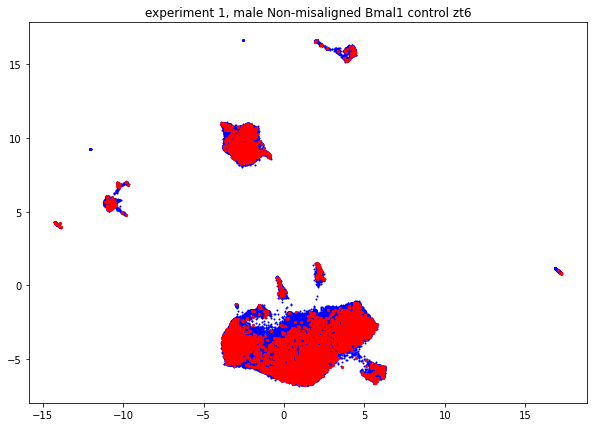

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

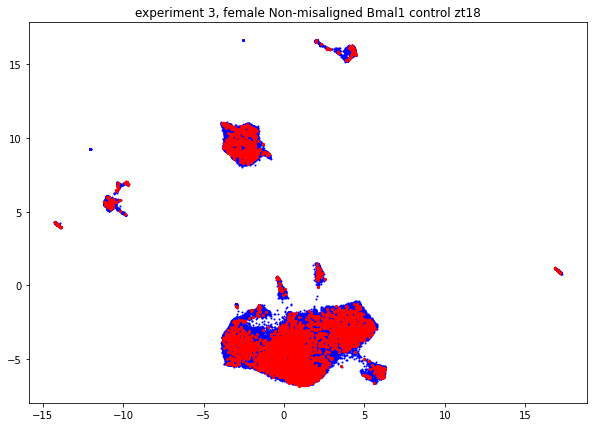

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

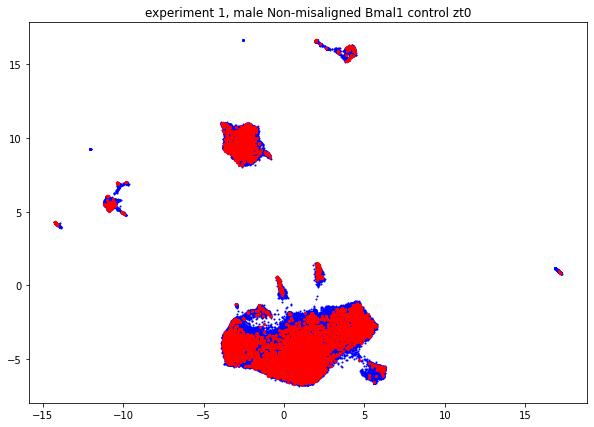

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

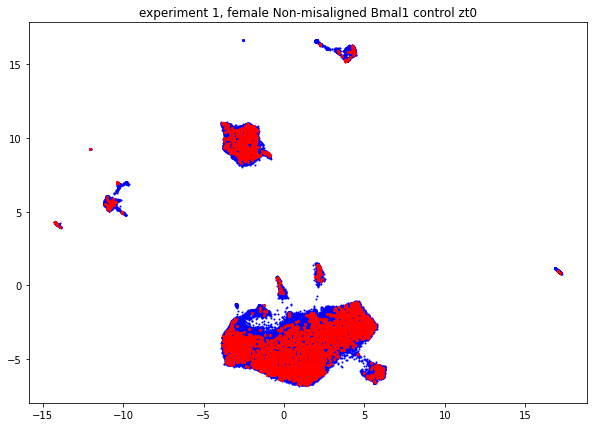

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

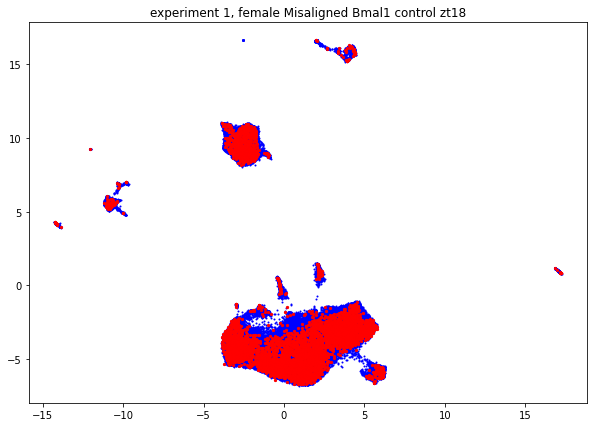

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

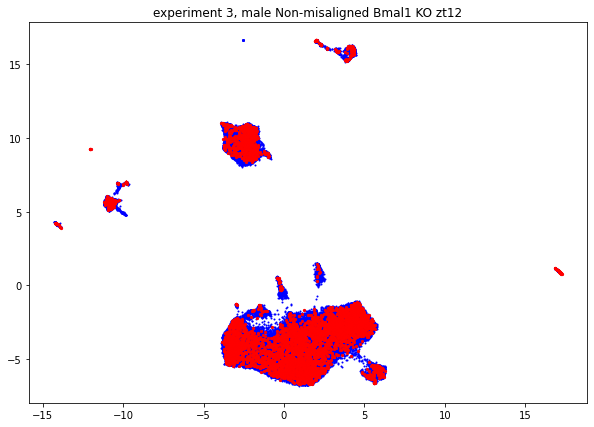

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

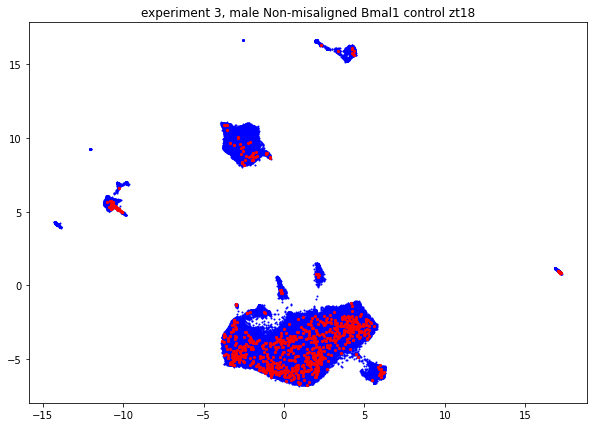

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

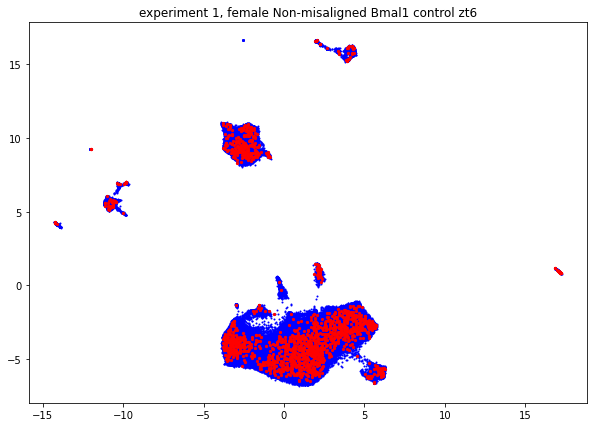

In [31]:
# --- VIZ BY SAMPLE ---


unique_sample_ids = adata.obs['sample_id'].unique()

for sample_id in unique_sample_ids:
    
    # ** indicator for if is the sample or not **
    sample_id_indicator_indices = np.where(adata.obs['sample_id'] == sample_id)[0]
    
    # ** get the sample description **
    sample_adata = adata[sample_id_indicator_indices,:]
    sex = sample_adata.obs['sex'].unique()[0]
    misaligned = "Misaligned" if sample_adata.obs['misaligned'].unique()[0] else "Non-misaligned"
    bmal1_ko = "Bmal1 KO" if sample_adata.obs['bmal1_ko'].unique()[0] else "Bmal1 control"
    zt = sample_adata.obs['zt'].unique()[0]
    batch = sample_adata.obs['batch'].unique()[0]
    description = 'experiment %s, %s %s %s zt%s' % (batch,sex,misaligned,bmal1_ko,zt)


    plt.clf()
    plt.figure(figsize=(10,7))
    plt.scatter(adata.obsm["X_scVI_umap"][:,0],adata.obsm["X_scVI_umap"][:,1],s=1,c = 'b')
    plt.scatter(adata.obsm["X_scVI_umap"][sample_id_indicator_indices,0],adata.obsm["X_scVI_umap"][sample_id_indicator_indices,1],s=5,c = 'r')
    plt.title(description)
    
    plt.show()



In [32]:
# --- ADD DESCRIPTION COLUMN ---

def get_description(row):
    sex = row['sex']
    misaligned = row['misaligned']
    misaligned = 'misaligned' if misaligned else "aligned"
    zt = row['zt']
    bmal1_ko = row['bmal1_ko']
    bmal1_ko = 'bmal1-ko' if bmal1_ko else "bmal1-control"
    description = "%s %s %s ZT%s" % (sex, misaligned, bmal1_ko, zt)
    return description

print("Labeling description")
adata.obs['description'] = adata.obs.apply(lambda row: get_description(row), axis=1)




Labeling description


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

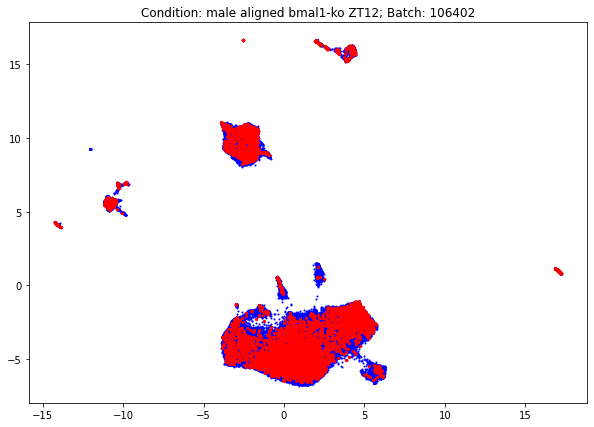

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

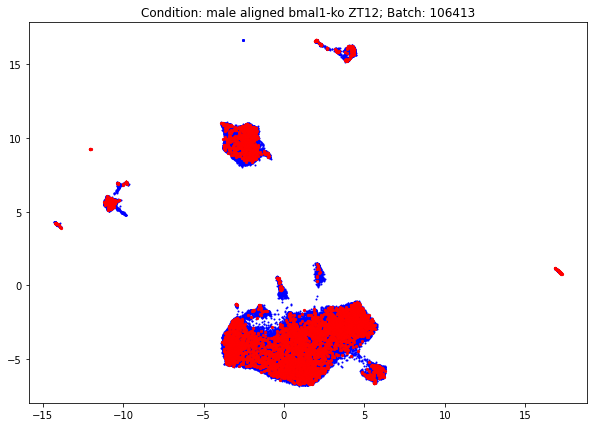

------------------------------------------
------------------------------------------
------------------------------------------


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

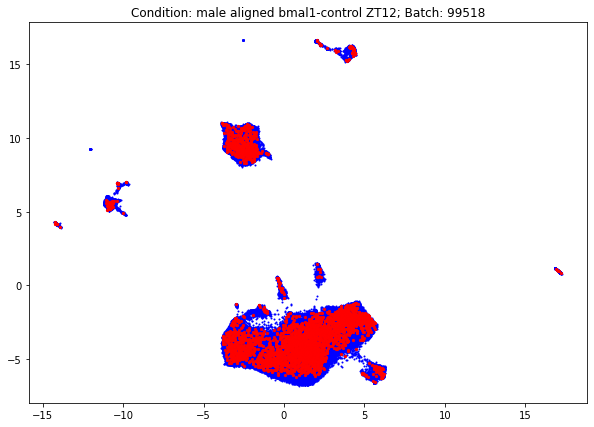

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

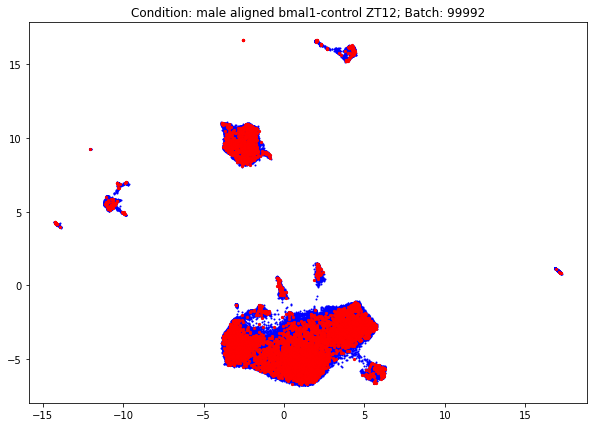

------------------------------------------
------------------------------------------
------------------------------------------


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

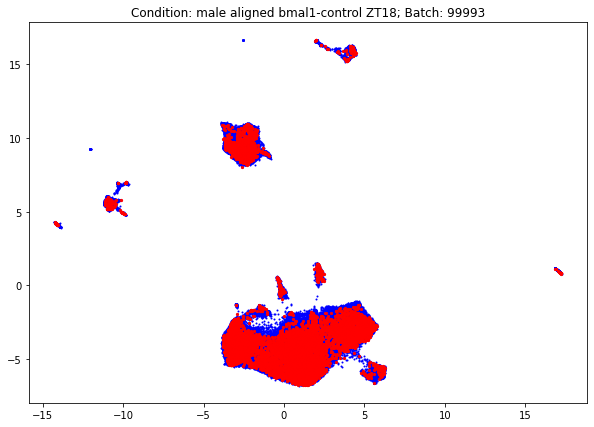

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

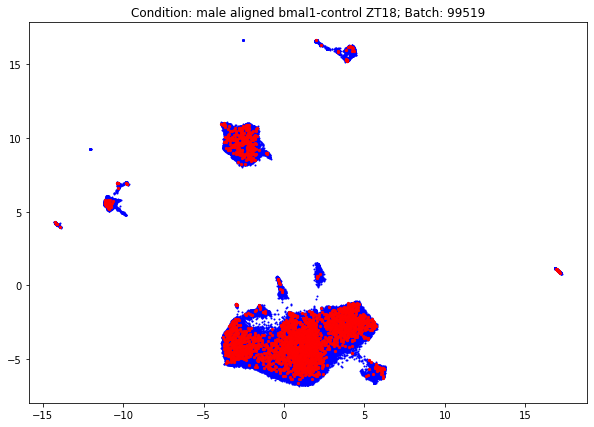

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

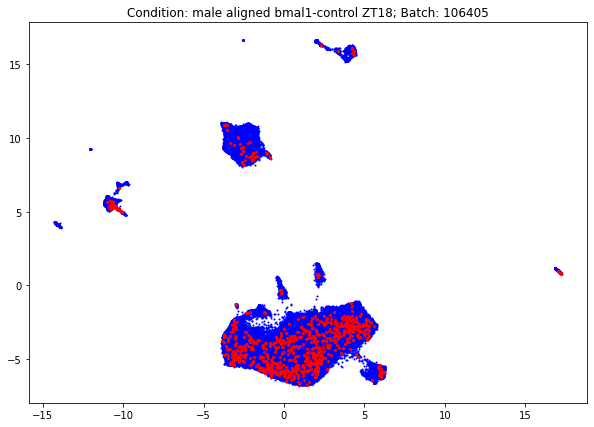

------------------------------------------
------------------------------------------
------------------------------------------


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

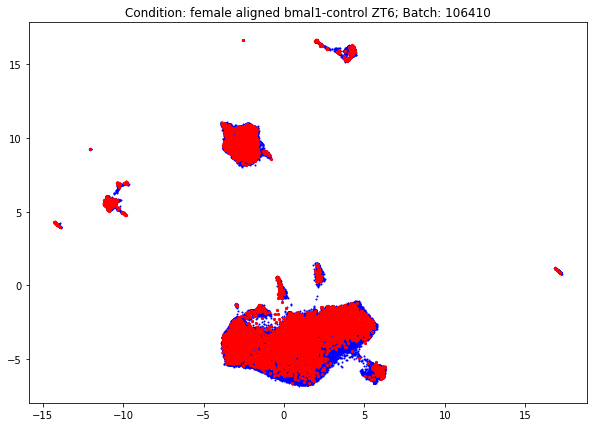

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

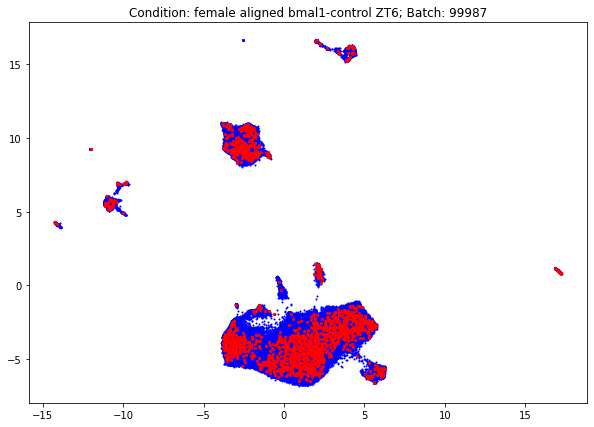

------------------------------------------
------------------------------------------
------------------------------------------


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

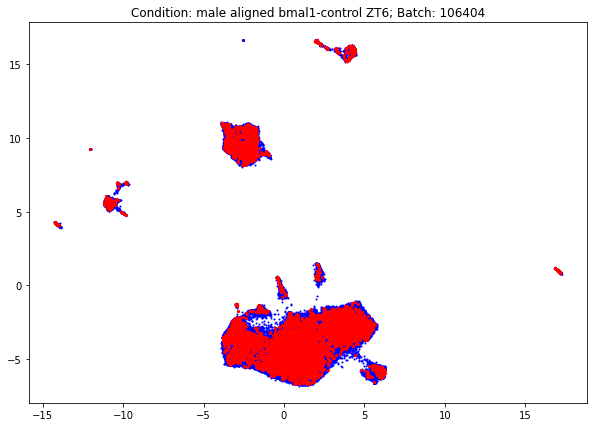

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

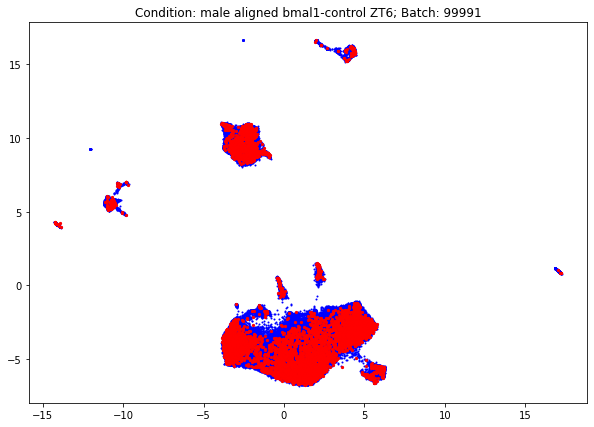

------------------------------------------
------------------------------------------
------------------------------------------


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

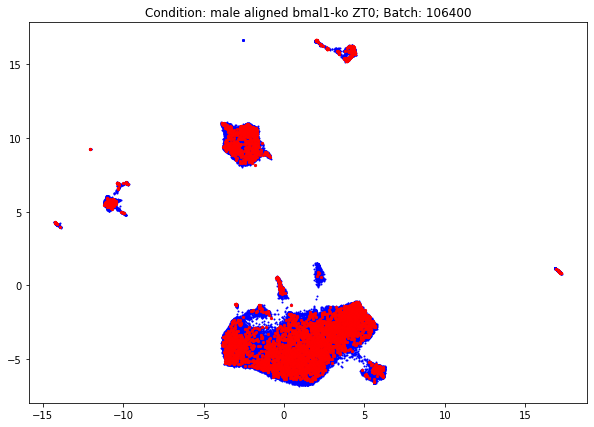

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

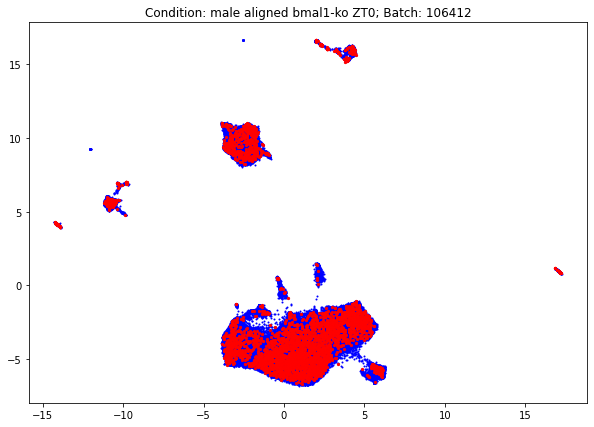

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


------------------------------------------
------------------------------------------
------------------------------------------


<Figure size 432x288 with 0 Axes>

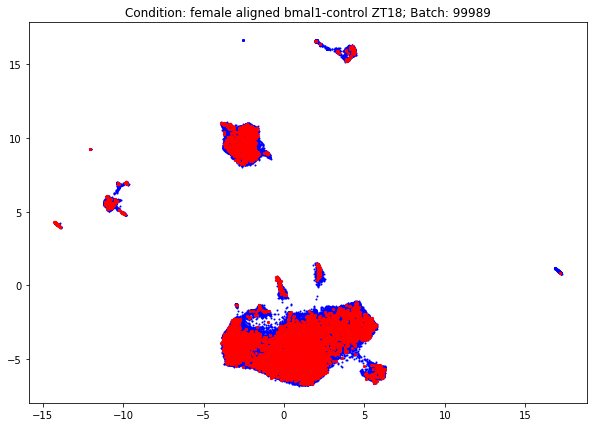

/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


<Figure size 432x288 with 0 Axes>

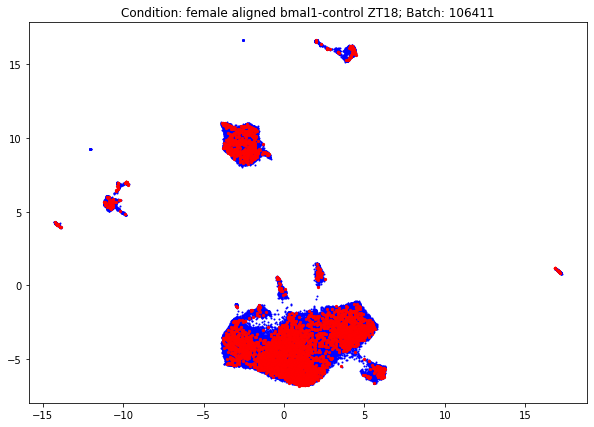

------------------------------------------
------------------------------------------
------------------------------------------


In [33]:
# --- LOOK AT BATCH EFFECTS FOR SAME CONDITIONS ---

# get unique conditions
unique_conditions = adata.obs['description'].unique()

# for each unique condition, figure out if there are multiple batches
unique_condition = unique_conditions[0]
for unique_condition in unique_conditions:

    # limit to condition
    condition_adata = adata[adata.obs['description'] == unique_condition]

    # see if multiple batches, if not continue to the next condition
    unique_batches_per_condition = condition_adata.obs['sample_id'].unique()
    num_batches_per_condition = len(unique_batches_per_condition)
    if num_batches_per_condition < 2:
        continue


    # for each condition-batch combo, viz
    for z, unique_batch in enumerate(unique_batches_per_condition):


        # limit to cluster and condition and batch
        condition_batch_adata = condition_adata[condition_adata.obs['sample_id'] == unique_batch]

        # 
        plt.clf()
        plt.figure(figsize=(10,7))
        plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=1,c='b')
        plt.scatter(condition_batch_adata.obsm['X_scVI_umap'][:,0],condition_batch_adata.obsm['X_scVI_umap'][:,1],s=5,c='r')
        plt.title("Condition: %s; Batch: %s" % (unique_condition, unique_batch))
        plt.show()
    
    print("------------------------------------------")
    print("------------------------------------------")
    print("------------------------------------------")
